# Machine Learning 2 - Assignment #2
# Data Science Specialization
# University of Antioquia

**Professor**: Hernán Felipe Garcáa Arias, PhD

## Overview

In this assignment, you will explore **dimensionality reduction techniques** and their impact on clustering tasks. You will apply **PCA**, **Kernel PCA**, **t-SNE**, and **UMAP** to project high-dimensional data into a lower-dimensional space and analyze whether these techniques improve the separability of clusters.

Furthermore, you will evaluate the effectiveness of these embeddings by performing **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** on the transformed datasets.

## Objectives

By the end of this assignment, students will be able to:
1. Implement and compare different dimensionality reduction techniques.
2. Analyze the quality of embeddings and their suitability for clustering.
3. Apply DBSCAN to assess the separability of clusters in reduced feature spaces.

## Datasets

Students can choose one of the following datasets:

* **FIFA 23 Players Dataset**: Contains detailed attributes of professional soccer players. The goal is to investigate whether dimensionality reduction can enhance player segmentation based on skill sets.
  - Features of interest: Age, Overall rating, Potential, Value, Wage, Shooting, Passing, Dribbling, Defending, and Physicality.
  
Dataset available on Kaggle [FIFA 23 Dataset - Kaggle](https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database?select=FIFA23_official_data.csv)

* **EastWestAirlines Dataset**: Contains airline customer behavior data. The objective is to assess whether dimensionality reduction aids in segmenting customer profiles based on usage patterns. Dataset available here

## Tasks

1. **Dimensionality Reduction**: Implement the following techniques and visualize their embeddings:
   * **Principal Component Analysis (PCA)**
   * **Kernel PCA**
   * **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
   * **UMAP (Uniform Manifold Approximation and Projection)**
  
   For each technique, analyze:
   * How well the data is preserved in lower dimensions.
   * Whether clusters appear more defined.
  
2. **Clustering with DBSCAN**: Apply **DBSCAN** to the reduced-dimensional data and evaluate:
   * How clustering performance is affected by different embeddings.
   * The number of clusters detected in each case.
   * The presence of noise (points classified as outliers).

3. **Comparison and Analysis**:
   * Compare the four dimensionality reduction methods in terms of cluster separability.
   * Identify which method best preserves structure for clustering.
   * Discuss whether the reduced feature space provides a meaningful representation for classification or decision-making.

## Deliverables

* Teams must submit an **IPYNB notebook (Jupyter notebook)** containing:
  - Implementations of **PCA**, **Kernel PCA**, **t-SNE**, and **UMAP**.
  - Visual comparisons of embeddings (e.g., scatter plots).
  - Application of **DBSCAN** to analyze clustering behavior in the embedded space.
  - Interpretation and discussion of findings.

* The notebook should be well-documented with **Markdown cells** explaining each step and analysis.

## Hints and Useful Links

* **PCA and Kernel PCA**: [Scikit-learn: PCA and Kernel PCA](https://scikit-learn.org/stable/modules/decomposition.html).
* **t-SNE**: Scikit-learn: [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).
* **UMAP**: [UMAP Documentation](https://umap-learn.readthedocs.io/en/latest/).
* **DBSCAN**: [Scikit-learn: DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html).

## Grading Rubric

* **Correctness of Implementation (40%)**: Accurate implementation of dimensionality reduction techniques and clustering.
* **Evaluation and Analysis (30%)**: Comparison of embeddings and their effects on clustering.
* **Visualization and Reporting (20%)**: Well-structured figures and discussion.
* **Code Quality (10%)**: Readability, documentation, and organization.

## Submission

Please submit your Jupyter notebooks in IPYNB format, including all code, analysis, and documentation. The deadline for this assignment is **19/03/2025**.

## Librerias y configuraciones previas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import multivariate_normal
from sklearn.metrics import rand_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA

## Funciones

In [2]:
# Funciones de conversion
def convert_mk_to_numeric(value):
    if isinstance(value, str):  # Asegurar que el valor es una cadena
        if 'M' in value:
            return float(value.replace('M', '')) * 1e6
        elif 'K' in value:
            return float(value.replace('K', '')) * 1e3
        else:
            return float(value)
    return value  # Si no es string, devolver el valor original

def convert_height_to_numeric(height):
    if isinstance(height, str):  # Asegurar que el valor es una cadena
        return float(height.replace('cm', ''))
    return height  # Si no es string, devolver el valor original

def convert_weight_to_numeric(weight):
    if isinstance(weight, str):  # Asegurar que el valor es una cadena
        return float(weight.replace('kg', ''))
    return weight  # Si no es string, devolver el valor original

## Dataset Fifa 23

### 1. Carga de datos



Se a carga el dataset como un dataframe mostrando las primeras filas para inspección:

In [3]:
# Se carga el dataset
csv_file = 'FIFA23_official_data.csv'
df_players = pd.read_csv(csv_file)
# Renombrado de las columnas
df_players.columns = df_players.columns.str.replace(' ', '_')
df_players.columns = df_players.columns.str.lower()
df_players.columns

Index(['id', 'name', 'age', 'photo', 'nationality', 'flag', 'overall',
       'potential', 'club', 'club_logo', 'value', 'wage', 'special',
       'preferred_foot', 'international_reputation', 'weak_foot',
       'skill_moves', 'work_rate', 'body_type', 'real_face', 'position',
       'joined', 'loaned_from', 'contract_valid_until', 'height', 'weight',
       'release_clause', 'kit_number', 'best_overall_rating'],
      dtype='object')

In [4]:
# Selección de las columnas a utilizar
features_selected = ['age', 'overall', 'potential', 'special', 'value', 'wage', 'height', 'weight', 'international_reputation']
df = df_players[features_selected]
df.head(3)

,age,overall,potential,special,value,wage,height,weight,international_reputation
0,27,87,88,2312,€91M,€115K,189cm,82kg,4.0
1,27,86,87,2305,€78.5M,€190K,179cm,69kg,3.0
2,30,85,85,2303,€46.5M,€46K,172cm,69kg,2.0


In [5]:
# Columna Value
df['value'] = df['value'].str[1:]
df['value']= df['value'].apply(convert_mk_to_numeric)

# Columna Wage
df['wage'] = df['wage'].str[1:]
df['wage'] = df['wage'].apply(convert_mk_to_numeric)

# Columna Height
df['height'] = df['height'].apply(convert_height_to_numeric)

# Columna Weight
df['weight'] = df['weight'].apply(convert_weight_to_numeric)

# Inspeccion del frame
df.head(3)

<ipython-input-5-776b506388c7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value'] = df['value'].str[1:]
<ipython-input-5-776b506388c7>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value']= df['value'].apply(convert_mk_to_numeric)
<ipython-input-5-776b506388c7>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

,age,overall,potential,special,value,wage,height,weight,international_reputation
0,27,87,88,2312,91000000.0,115000.0,189.0,82.0,4.0
1,27,86,87,2305,78500000.0,190000.0,179.0,69.0,3.0
2,30,85,85,2303,46500000.0,46000.0,172.0,69.0,2.0


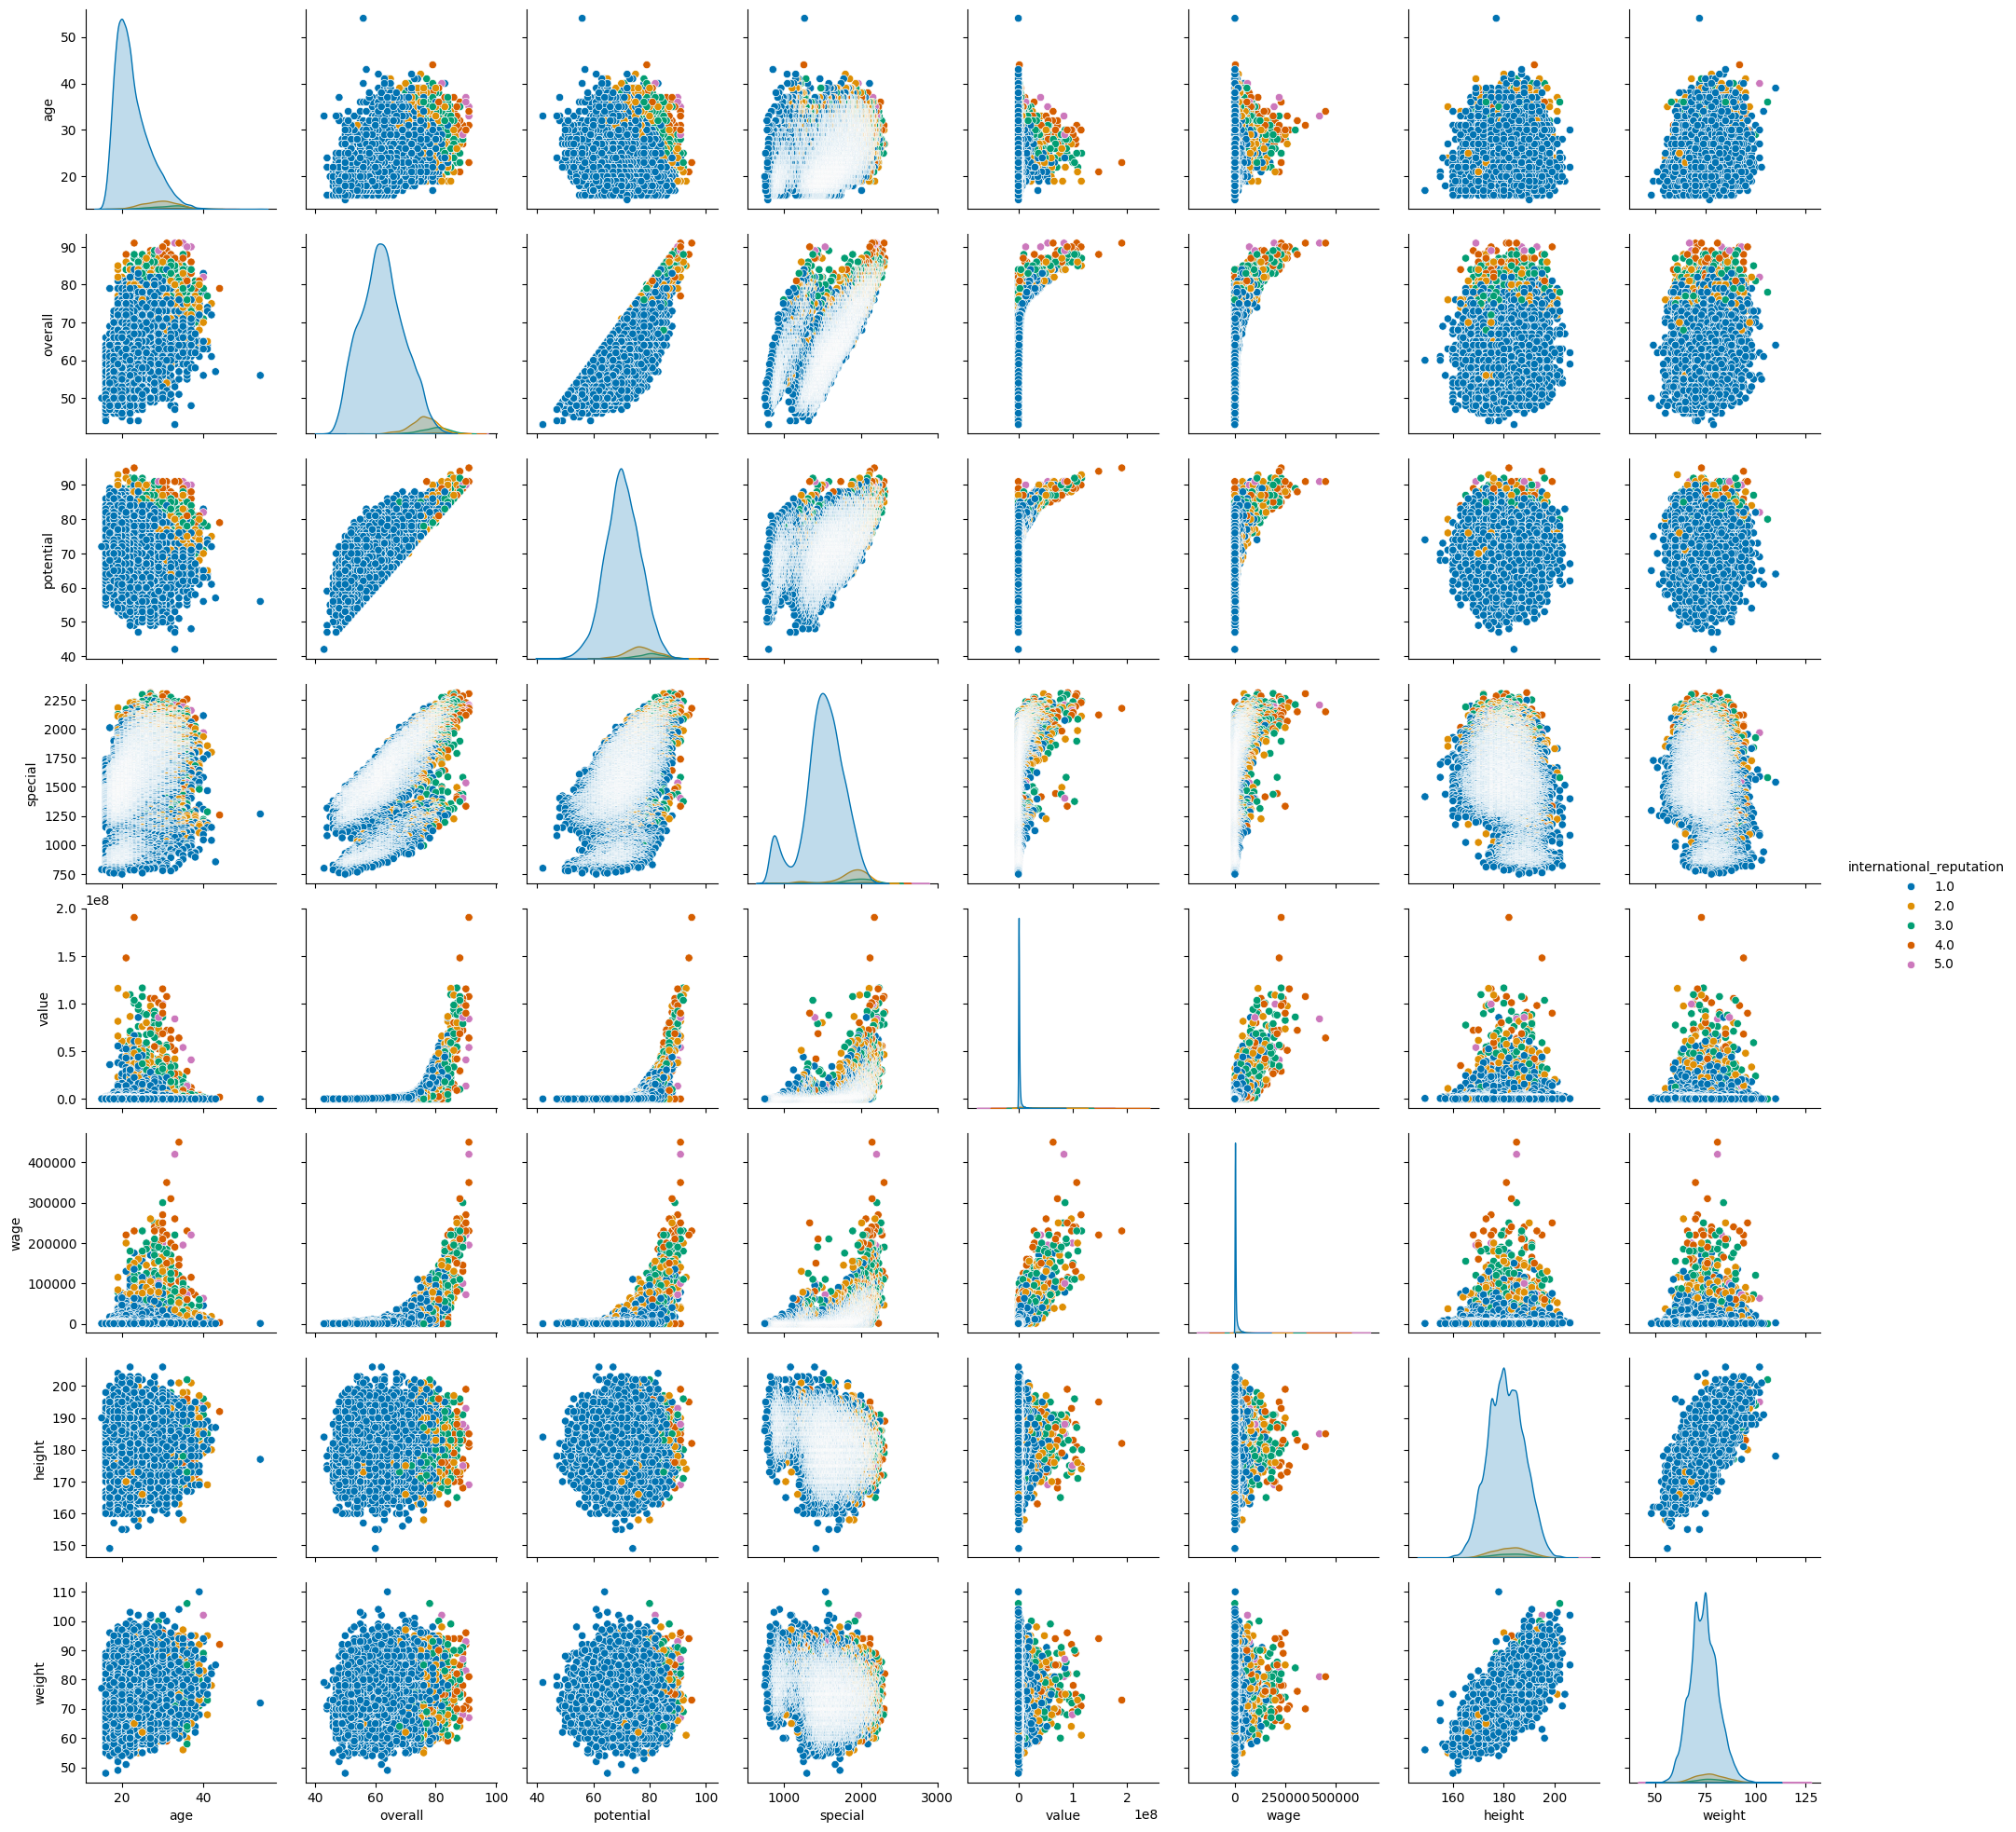

In [ ]:
# plt.figure(figsize=(12,7))
# g = sns.PairGrid(df)
# g.map_diag(sns.histplot)
# g.map_lower(sns.scatterplot)

sns.pairplot(df, palette = 'colorblind', hue = 'international_reputation')
plt.show()


In [6]:
X = df.drop('international_reputation', axis=1)
y = df['international_reputation']
X.head()

,age,overall,potential,special,value,wage,height,weight
0,27,87,88,2312,91000000.0,115000.0,189.0,82.0
1,27,86,87,2305,78500000.0,190000.0,179.0,69.0
2,30,85,85,2303,46500000.0,46000.0,172.0,69.0
3,31,91,91,2303,107500000.0,350000.0,181.0,70.0
4,25,86,89,2296,89500000.0,110000.0,172.0,68.0


In [7]:
# Data standardization
sc = StandardScaler()

X_std = pd.DataFrame(sc.fit_transform(X), columns = X.columns)
X_std.head()

,age,overall,potential,special,value,wage,height,weight
0,0.834593,2.940553,2.606387,2.707670,11.256167,5.216321,1.164354,1.099003
1,0.834593,2.816114,2.453240,2.683185,9.661994,8.879119,-0.271955,-0.762782
2,1.481188,2.691675,2.146945,2.676189,5.580910,1.846548,-1.277372,-0.762782
3,1.696720,3.438311,3.065830,2.676189,13.360476,16.693086,0.015307,-0.619568
4,0.403530,2.816114,2.759535,2.651703,11.064866,4.972135,-1.277372,-0.905997


### 2. Dimensionality Reduction

#### PCA

In [ ]:
#define PCA model to use
# N = 8
pca = PCA(n_components = None)

#fit PCA model to data
pca_fit = pca.fit(X_std)
pca.explained_variance_

array([3.46273013, 1.90745828, 1.13044084, 0.75013634, 0.30088867,
       0.21671265, 0.17933284, 0.05275327])

In [ ]:
pca.explained_variance_ratio_

array([0.43281676, 0.23841878, 0.1412971 , 0.09376173, 0.03760895,
       0.02708755, 0.02241534, 0.00659379])

In [ ]:
pca.n_components_

8

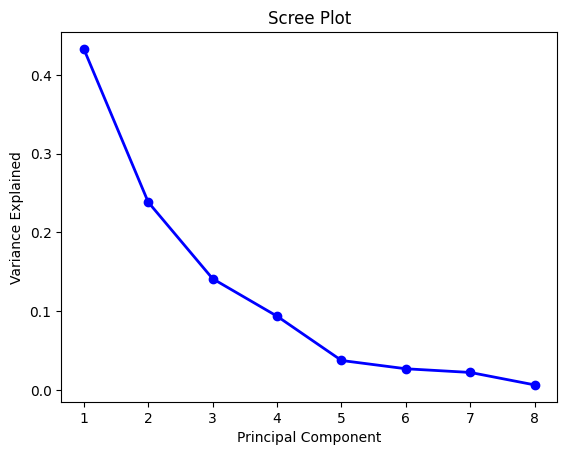

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

In [ ]:
np_pca = pca.explained_variance_ratio_
print(f"Variance by PCA {np_pca}")
print(f"Cummulative sum {np.cumsum(np_pca)}")

Variance by PCA [0.43281676 0.23841878 0.1412971  0.09376173 0.03760895 0.02708755
 0.02241534 0.00659379]
Cummulative sum [0.43281676 0.67123554 0.81253264 0.90629438 0.94390333 0.97099088
 0.99340621 1.        ]


Vamos a elegir 4 componentes pues estos explican el 90% de la varianza

In [ ]:
pca = PCA(n_components=4)
pca

PCA(n_components=4)

In [ ]:
pca.fit(X_std)
pca

PCA(n_components=4)

In [ ]:
pca.components_

array([[ 0.26398911,  0.49614718,  0.39143129,  0.39613786,  0.42205826,
         0.43819343,  0.01157418,  0.06102008],
       [ 0.15690398,  0.04299028, -0.04761852, -0.27121411,  0.00446022,
         0.02923251,  0.66917064,  0.67010789],
       [ 0.74967064,  0.18641013, -0.3884153 ,  0.25563698, -0.3452769 ,
        -0.21610859, -0.13976998,  0.03967099],
       [-0.20715142,  0.25901022,  0.56664269,  0.28374399, -0.46201332,
        -0.50195534,  0.12173701,  0.0903993 ]])

In [ ]:
pca.explained_variance_ratio_

array([0.43281676, 0.23841878, 0.1412971 , 0.09376173])

Salida espacio latente

In [ ]:
Z = pd.DataFrame(pca.fit_transform(X_std),
             columns=['PC1', 'PC2', 'PC3', 'PC4'])

Z.head()

,PC1,PC2,PC3,PC4
0,10.889157,1.117189,-4.279291,-4.743844
1,11.559719,-0.982998,-4.363498,-6.314990
2,6.730290,-1.766989,-0.715351,-1.363553
3,17.330096,-0.315138,-6.841067,-11.570385
4,10.413050,-1.933399,-4.318873,-4.883424


In [ ]:
# prompt: concatenar data_pca con la columna international_reputation de df_players y llevarla a un nuevo dataframe

import pandas as pd

projected_df = pd.concat([Z, df_players['international_reputation']], axis=1)
projected_df.head()

,PC1,PC2,PC3,PC4,international_reputation
0,10.889157,1.117189,-4.279291,-4.743844,4.0
1,11.559719,-0.982998,-4.363498,-6.314990,3.0
2,6.730290,-1.766989,-0.715351,-1.363553,2.0
3,17.330096,-0.315138,-6.841067,-11.570385,4.0
4,10.413050,-1.933399,-4.318873,-4.883424,3.0


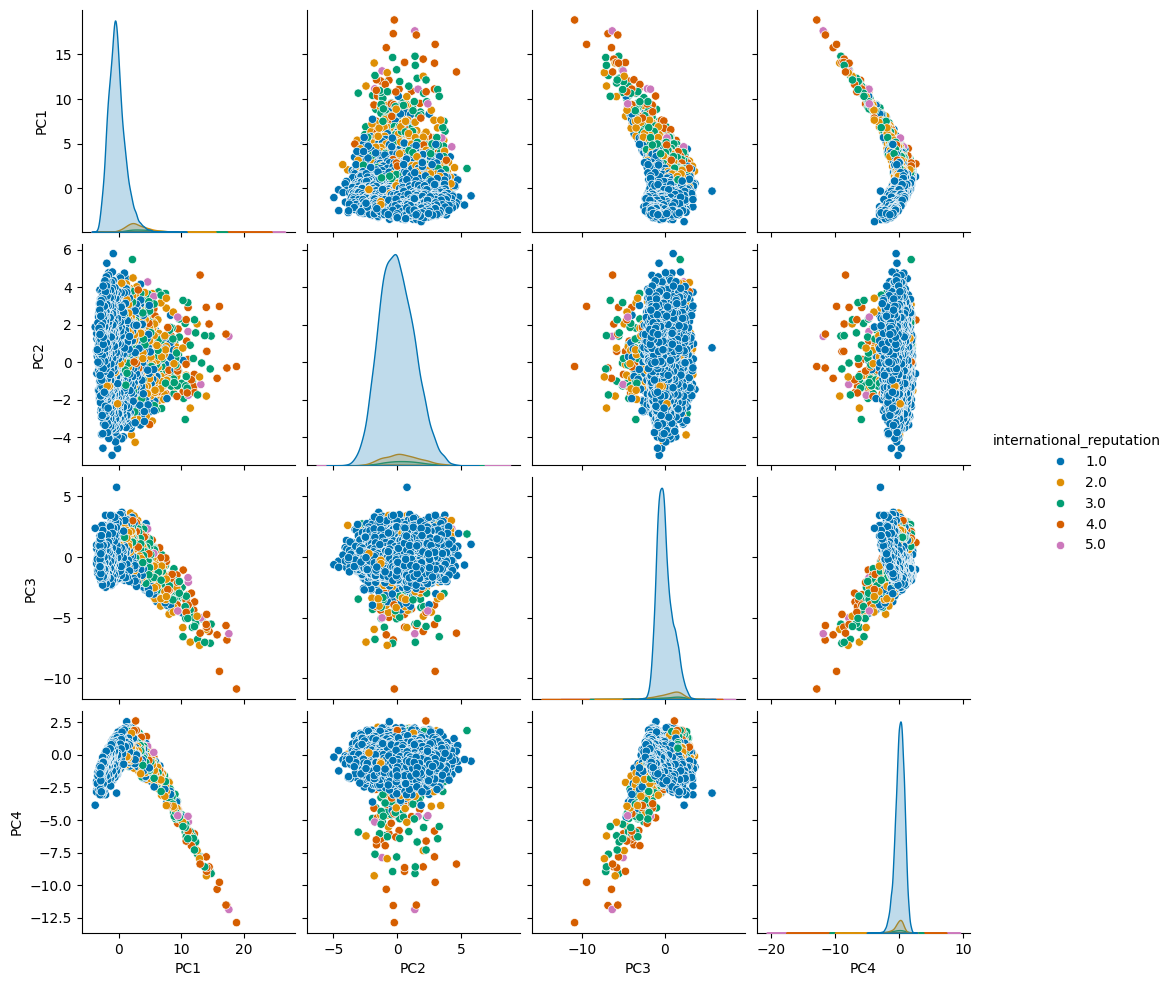

In [ ]:
sns.pairplot(projected_df, hue='international_reputation', palette = 'colorblind')
plt.show()


Comparaciones de tamaño

In [ ]:
print(df.shape)
print(projected_df.shape)

(17660, 9)
(17660, 5)


#### Kernel PCA

Recordemos los puntos de partida

In [ ]:
# Datos originales sin estandarizar
X.head()

,age,overall,potential,special,value,wage,height,weight
0,27,87,88,2312,91000000.0,115000.0,189.0,82.0
1,27,86,87,2305,78500000.0,190000.0,179.0,69.0
2,30,85,85,2303,46500000.0,46000.0,172.0,69.0
3,31,91,91,2303,107500000.0,350000.0,181.0,70.0
4,25,86,89,2296,89500000.0,110000.0,172.0,68.0


In [ ]:
# Datos estandarizados
X_std.head()

,age,overall,potential,special,value,wage,height,weight
0,0.834593,2.940553,2.606387,2.707670,11.256167,5.216321,1.164354,1.099003
1,0.834593,2.816114,2.453240,2.683185,9.661994,8.879119,-0.271955,-0.762782
2,1.481188,2.691675,2.146945,2.676189,5.580910,1.846548,-1.277372,-0.762782
3,1.696720,3.438311,3.065830,2.676189,13.360476,16.693086,0.015307,-0.619568
4,0.403530,2.816114,2.759535,2.651703,11.064866,4.972135,-1.277372,-0.905997


In [ ]:
# Salida
y.head()

,international_reputation
0,4.0
1,3.0
2,2.0
3,4.0
4,3.0


Parametros basicos

In [10]:
KERNEL ='rbf' # 'linear', 'rbf', 'poly', 'sigmoid'
GAMMA = 10
N_COMPONENTS = 3

In [11]:
kpca = KernelPCA(kernel = KERNEL, n_components = N_COMPONENTS, fit_inverse_transform = True, gamma = GAMMA)
kpca


KernelPCA(fit_inverse_transform=True, gamma=10, kernel='rbf', n_components=3)

In [ ]:
X_kpca = kpca.fit_transform(X_std)
X_kpca

* https://www.codecademy.com/article/principal-component-analysis-intro
* https://github.com/matworx/aai-url-notebooks/blob/main/06_PCA_example.ipynb
* https://github.com/zorzalerrante/intro_machine_learning/blob/master/05.09-Principal-Component-Analysis.ipynb

**Enlaces**:
* https://github.com/zorzalerrante/intro_machine_learning/blob/master/05.09-Principal-Component-Analysis.ipynb
* https://gitlabio.z6.web.core.windows.net/aai-url/
  * https://gitlabio.z6.web.core.windows.net/aai-url/assets/05-lecture/05-lecture.pdf
  * https://github.com/matworx/aai-url-notebooks/blob/main/06_PCA.ipynb
  * https://github.com/matworx/aai-url-notebooks/blob/main/06_PCA_example.ipynb
  * https://gitlabio.z6.web.core.windows.net/aai-url/assets/02-lecture/02-lecture.pdf
  



* https://www.datacamp.com/tutorial/principal-component-analysis-in-python
* https://www.kaggle.com/code/shrutimechlearn/step-by-step-pca-with-iris-dataset
* https://scikit-learn.org/1.3/auto_examples/decomposition/plot_pca_iris.html
* https://campus.datacamp.com/courses/dimensionality-reduction-in-python/feature-extraction?ex=5
* https://web.stanford.edu/class/stats202/notes/Unsupervised/PCA.html
* https://www.codecademy.com/article/principal-component-analysis-intro

https://github.com/matworx/aai-url-notebooks/blob/main/06_PCA_example.ipynb

* https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.09-Principal-Component-Analysis.ipynb
* https://github.com/tirthajyoti/Machine-Learning-with-Python/blob/master/Clustering-Dimensionality-Reduction/Principal%20Component%20Analysis.ipynb
* https://github.com/jeffprosise/Machine-Learning/blob/master/PCA.ipynb
* https://cs.colby.edu/courses/S23/cs251/projects/p4pca/p4pca251.html


---
* https://www.codecademy.com/article/principal-component-analysis-intro
* https://www.codecademy.com/article/eda-prior-to-unsupervised-clustering
* https://www.codecademy.com/article/eda-prior-to-fitting-a-classification-model
* https://www.codecademy.com/article/eda-data-visualization


## Dataset aerolineas

La siguiente tabla resume la información del dataset:

| Campo               | Descripción |
|---------------------|-------------|
| ID#                | ID único |
| Balance           | Número de millas elegibles para viajes con premio |
| Qual_miles        | Número de millas que califican para el estatus Topflight |
| cc1_miles        | Número de millas ganadas con la tarjeta de crédito de viajero frecuente en los últimos 12 meses |
| cc2_miles        | Número de millas ganadas con la tarjeta de crédito Rewards en los últimos 12 meses |
| cc3_miles        | Número de millas ganadas con la tarjeta de crédito para pequeñas empresas en los últimos 12 meses |
| Bonus_miles      | Número de millas ganadas por transacciones de bonificación no relacionadas con vuelos en los últimos 12 meses |
| Bonus_trans      | Número de transacciones de bonificación no relacionadas con vuelos en los últimos 12 meses |
| Flight_miles_12mo | Número de millas de vuelo en los últimos 12 meses |
| Flight_trans_12  | Número de transacciones de vuelo en los últimos 12 meses |
| Days_since_enroll | Número de días desde la fecha de inscripción |
| Award?           | Variable indicadora para el último premio (1= no nulo, 0= nulo) |

### 1. Carga de datos

In [ ]:
# Se carga el dataset
xlsx_file = 'EastWestAirlines.xlsx'
df_airlines = pd.read_excel(xlsx_file, sheet_name='data')
df_airlines.columns = df_airlines.columns.str.lower()
df_airlines.head(3)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0


In [ ]:
df2 = df_airlines.drop(columns=['qual_miles','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
df2.head(3)